In [3]:
# Adjacency matrix

%load_ext autoreload
%autoreload 2
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math

# import import_ipynb
from graph_functions import *
from iterative_pruning_func import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from pprint import pprint

G, n, _ = generate_graphs(26)[1]     # prism
fully_infect(G)
A = nx.adjacency_matrix(G)

for row in A:
    print(" ".join(f"{x:0}" for x in row))

number of graphs for n=26 : 2
0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1
1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0
0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0
0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1
1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0
0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0
0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0
0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0
0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0
0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 

In [6]:
def display_adj_matrix(G):
    # adjacency matrix
    A = nx.adjacency_matrix(G).toarray()
    np.fill_diagonal(A, 0)  # remove self-loops visually

    nodes = list(G.nodes())
    n = len(nodes)

    # infected status in node order
    infected = np.array([G.nodes[n].get("infected", False) for n in nodes])

    # build display matrix:
    # 0 = empty (white)
    # 1 = connected (blue)
    # 2 = infected ↔ infected connection (green)
    M = np.zeros_like(A)

    for i in range(n):
        for j in range(n):
            if A[i, j] > 0:
                if infected[i] and infected[j]:
                    M[i, j] = 2
                else:
                    M[i, j] = 1

    # colormap and normalization
    cmap = ListedColormap(["white", "steelblue", "seagreen"])
    norm = BoundaryNorm([0, 0.5, 1.5, 2.5], cmap.N)

    fig, ax = plt.subplots()
    ax.imshow(M, cmap=cmap, norm=norm)

    # ticks and labels
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(nodes, rotation=90)
    ax.set_yticklabels(nodes)

    # color labels + overlay infected rows/columns
    for i, node in enumerate(nodes):
        if infected[i]:
            ax.get_xticklabels()[i].set_color("red")
            ax.get_yticklabels()[i].set_color("red")

            # highlight row and column
            ax.axhspan(i - 0.5, i + 0.5, color="red", alpha=0.10)
            ax.axvspan(i - 0.5, i + 0.5, color="red", alpha=0.10)

    # light grid
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="lightgray", linewidth=0.5)

    ax.tick_params(which="both", bottom=False, left=False)
    plt.title("Adjacency Matrix (Infected Nodes Highlighted)")
    plt.tight_layout()
    plt.show()

number of graphs for n=26 : 2
initial removal


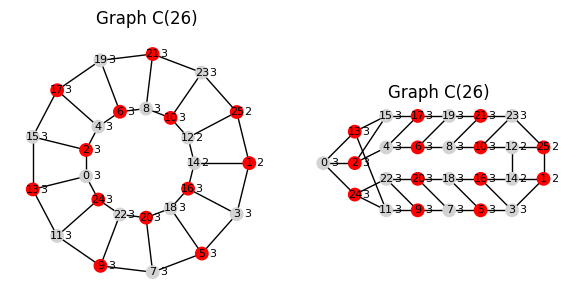

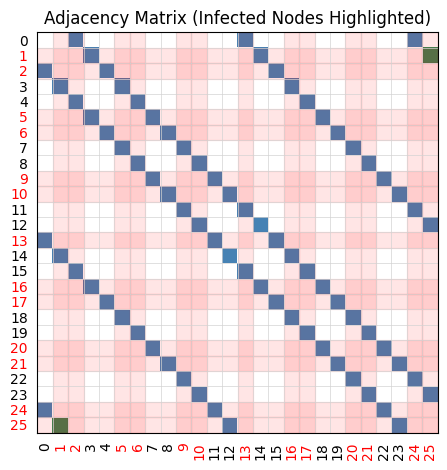

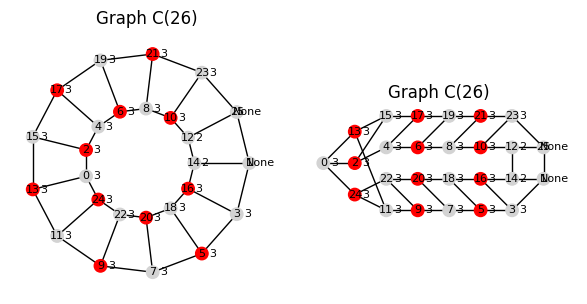

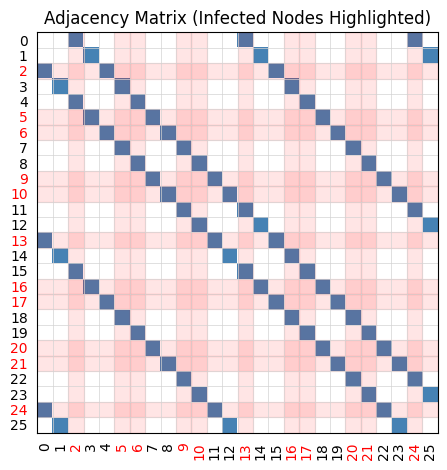

In [7]:
G, n, _ = generate_graphs(26)[1]     # prism
fully_infect(G)

# display_graph_stage(G, prism=True)

# 1. stage
print("initial removal")
minimise_infection(G, 0)
pc = calc_graph_values(G)
display_graph_stage(G, prism=True)
display_adj_matrix(G)


G.nodes[1]["infected"] = False
G.nodes[25]["infected"] = False

display_graph_stage(G, prism=True)
display_adj_matrix(G)